# MSBA 6690 — Lab 4: AAC NIL Bidding Simulation
### MSBA 6690 – Sports Analytics | Session 4

---

## Scenario

You are the analytics staff for an AAC athletic department. Your school has been assigned a NIL budget and a current roster with real strengths and weaknesses. A pool of 25 transfer-eligible athletes is available — 14 football, 11 basketball. Every school in the simulation is bidding on the same pool.

Your job is to use data — not intuition, not sports knowledge — to identify which athletes are worth the most to *your specific school*, build a principled bid strategy, compete in a live auction, and then evaluate what happened.

This notebook is your analytical workspace and your Lab 4 deliverable. Every decision you make should be documented here.

---

## Your School Assignment

> **Fill this in before you do anything else.**

In [1]:
# ── SCHOOL CONFIGURATION ──────────────────────────────────────────────────────
# Fill in your school assignment. Everything downstream references these variables.

MY_SCHOOL    = "USF"           # e.g. "Memphis", "Rice", "USF", "Tulane", "UTSA", "East Carolina", "North Texas"
MY_BUDGET    = 5100000            # Your NIL budget in dollars — from your school card
MY_SPORT_FOCUS = "Football"         # "Football", "Basketball", or "Balanced" — your assessment after reading the school card

# Sport-focus drives the planned budget split referenced in the Phase 1 reflection:
# football is the program's primary revenue driver and recent investment priority,
# so a "Football" focus allocates 60% of the budget to football targets and 40%
# to basketball. A "Balanced" focus would split 50/50 instead.
SPORT_BUDGET_SPLIT = {
    "Football":   {"Football": 0.60, "Basketball": 0.40},
    "Basketball": {"Football": 0.40, "Basketball": 0.60},
    "Balanced":   {"Football": 0.50, "Basketball": 0.50},
}

football_budget   = MY_BUDGET * SPORT_BUDGET_SPLIT[MY_SPORT_FOCUS]["Football"]
basketball_budget = MY_BUDGET * SPORT_BUDGET_SPLIT[MY_SPORT_FOCUS]["Basketball"]

print(f"School: {MY_SCHOOL}")
print(f"Budget: ${MY_BUDGET:,}")
print(f"Sport focus: {MY_SPORT_FOCUS}")
print(f"Planned football budget:   ${football_budget:,.0f}")
print(f"Planned basketball budget: ${basketball_budget:,.0f}")

School: USF
Budget: $5,100,000
Sport focus: Football


---
## Phase 1 — School Onboarding & Roster Gap Analysis

Before you touch the athlete pool, understand who you already are. Load your starting roster ratings, visualize your strengths and weaknesses, and write a clear analytical statement of what your school needs most.

This phase answers: *What does our school need, and why does the data say so?*

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
# LinearRegression / r2_score / mean_absolute_error were considered for the
# Option B (combined regression) approach in Phase 2, but were not used —
# see the sample-size note below for why we went with Option A instead.
import warnings
warnings.filterwarnings('ignore')

# Load the athlete pool
# Note: injury_history and academic_standing are already numeric
# injury_history:   None=0, Minor=1, Moderate=2, Significant=3
# academic_standing: Excellent=0, Good=1, Probation Risk=2, Ineligibility Risk=3
df = pd.read_csv('aac_nil_athlete_pool.csv')

print(f"Athlete pool loaded: {df.shape[0]} athletes, {df.shape[1]} columns")
print(f"\nSport breakdown:")
print(df['sport'].value_counts())

Athlete pool loaded: 25 athletes, 59 columns

Sport breakdown:
sport
Football      14
Basketball    11
Name: count, dtype: int64


In [3]:
# ── ENTER YOUR STARTING ROSTER RATINGS FROM YOUR SCHOOL CARD ─────────────────
# Copy the position ratings exactly from your school card document.
# These represent your current roster BEFORE the auction.

football_roster = {
    'QB':  58,
    'WR':  84,
    'RB':  76,
    'OL1': 79,
    'OL2': 77,
    'LB':  74,
    'CB':  72,
    'DE':  83,
    'DT':  80,
    'TE':  73,
    'S':   78,
}

basketball_roster = {
    'PG': 62,
    'SG': 61,
    'SF': 74,
    'PF': 81,
    'C':  83,
}

# Convert to DataFrames
fb_df = pd.DataFrame(list(football_roster.items()), columns=['position', 'current_rating'])
bk_df = pd.DataFrame(list(basketball_roster.items()), columns=['position', 'current_rating'])

# Pool averages by position for comparison
fb_pool = df[df['sport']=='Football'].groupby('position')['performance_score'].mean().reset_index()
fb_pool.columns = ['position','pool_avg']
bk_pool = df[df['sport']=='Basketball'].groupby('position')['performance_score'].mean().reset_index()
bk_pool.columns = ['position','pool_avg']

# Merge
fb_df = fb_df.merge(fb_pool, on='position', how='left').fillna(75)
fb_df['gap'] = fb_df['pool_avg'] - fb_df['current_rating']
bk_df = bk_df.merge(bk_pool, on='position', how='left').fillna(75)
bk_df['gap'] = bk_df['pool_avg'] - bk_df['current_rating']

print("Football roster gaps (positive = you are below pool average):")
print(fb_df.sort_values('gap', ascending=False).to_string(index=False))
print("\nBasketball roster gaps:")
print(bk_df.sort_values('gap', ascending=False).to_string(index=False))

Football roster gaps (positive = you are below pool average):
position  current_rating  pool_avg  gap
      QB              58      79.5 21.5
      LB              74      83.0  9.0
      CB              72      75.5  3.5
      DE              83      85.0  2.0
      TE              73      72.0 -1.0
       S              78      77.0 -1.0
     OL2              77      75.0 -2.0
      RB              76      73.5 -2.5
      WR              84      81.0 -3.0
     OL1              79      75.0 -4.0
      DT              80      74.0 -6.0

Basketball roster gaps:
position  current_rating  pool_avg  gap
      SG              61      81.0 20.0
      PG              62      77.0 15.0
      SF              74      79.5  5.5
      PF              81      76.5 -4.5
       C              83      76.0 -7.0


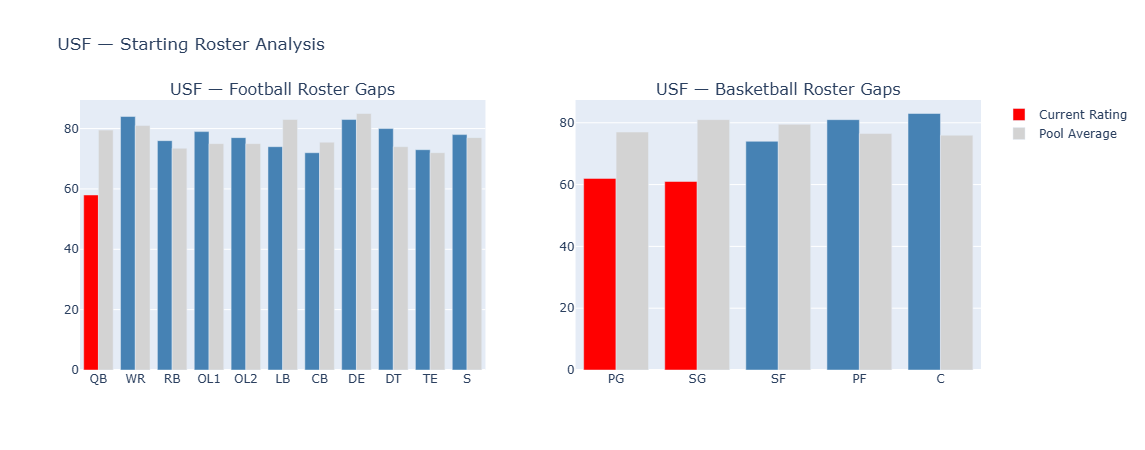

In [5]:
# ── PHASE 1 REQUIRED VISUAL: Roster Heatmap ───────────────────────────────────
# This visual is required for all schools — no menu choice here.
# Build a side-by-side bar chart comparing your current ratings to pool averages.
# Color bars red if your rating is more than 10 points below pool average
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        f'{MY_SCHOOL} — Football Roster Gaps',
        f'{MY_SCHOOL} — Basketball Roster Gaps'
    ]
)

# ── Football Chart ─────────────────────────────────────────────

fb_colors = ['red' if gap > 10 else 'steelblue' for gap in fb_df['gap']]

fig.add_trace(
    go.Bar(
        x=fb_df['position'],
        y=fb_df['current_rating'],
        name='Current Rating',
        marker_color=fb_colors
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Bar(
        x=fb_df['position'],
        y=fb_df['pool_avg'],
        name='Pool Average',
        marker_color='lightgray'
    ),
    row=1,
    col=1
)

# ── Basketball Chart ───────────────────────────────────────────

bk_colors = ['red' if gap > 10 else 'steelblue' for gap in bk_df['gap']]

fig.add_trace(
    go.Bar(
        x=bk_df['position'],
        y=bk_df['current_rating'],
        name='Current Rating',
        marker_color=bk_colors,
        showlegend=False
    ),
    row=1,
    col=2
)

fig.add_trace(
    go.Bar(
        x=bk_df['position'],
        y=bk_df['pool_avg'],
        name='Pool Average',
        marker_color='lightgray',
        showlegend=False
    ),
    row=1,
    col=2
)

# ── Layout ─────────────────────────────────────────────────────

fig.update_layout(
    title=f'{MY_SCHOOL} — Starting Roster Analysis',
    height=450,
    barmode='group',
    showlegend=True
)

fig.show()

### Phase 1 Reflection — Required

Answer all three questions in this cell before moving to Phase 2.

**1. What are your school's two most critical positional needs based on the gap analysis? Cite specific numbers.**

> *The two most critical positions based on the gap analysis are QB (+22) and SG (20)*

**2. What did your research on your school's institutional profile reveal? How does it affect your bidding priorities?** *(Reference your research prompt answers from the school card)*

> *Our research on the school institutional profile revealed that we have the largest budget in the conference. In terms of athletics the school has recently had improved success in both football and basketball, with winning records in both and the basketball team recently making March madness. Ultimately football is the dominant sport in this case because it drives the most money into the school and large investments are being pumped into the football program with hundreds of millions of dollars going into new facilities. *

**3. How will you allocate your budget across football and basketball? What is your reasoning?**

*We are moving forward with a 60/40 split meaning 3.2M towards football and 1.9M towards basketball. This is largely due to the schools recent investments in the football program and faciilities as well as the program bringing in the most money for the school*

---
## Phase 2 — Athlete Valuation Model

Now you model the athlete pool. Your goal is to predict `base_nil_value` for each athlete using regression, then apply a **positional need multiplier** to produce a school-adjusted valuation.

This phase answers: *What is each athlete worth — and what are they worth specifically to us?*

**Important:** Run separate models for football and basketball. The variables that predict value differ by sport.

In [6]:
# ── SPLIT BY SPORT ────────────────────────────────────────────────────────────
fb = df[df['sport'] == 'Football'].copy()
bk = df[df['sport'] == 'Basketball'].copy()

print(f"Football athletes: {len(fb)}")
print(f"Basketball athletes: {len(bk)}")

Football athletes: 14
Basketball athletes: 11


### A Note on Sample Size and Modeling Choice

Before you build your valuation model, there's an important analytical 
reality to acknowledge:

- Football subset: 14 athletes
- Basketball subset: 11 athletes

Running a regression with 8–10 features on 11–14 observations is a 
problem. With more features than observations (or close to it), 
regression will overfit — it will fit the noise in your small sample 
rather than finding real patterns. An R² of 0.95 on 11 observations 
means almost nothing.

**You have two options:**

**Option A: Weighted Composite Model (recommended)**
Assign weights to each variable based on your analytical judgment. 
Normalize variables to a common scale. Compute a composite score. 
Convert to a dollar valuation. This is transparent, defensible, and 
realistic — real NIL decisions are made this way.

**Option B: Combined Regression with Caveats**
Run one regression on all 25 athletes using only shared variables 
(performance_score, physical_rating, recruiting_stars, 
social_media_followers, injury_history, academic_standing). Add a 
sport dummy variable. Acknowledge the small sample limitation explicitly 
in your markdown. Use coefficients directionally, not literally.

**Either approach is acceptable - but you must justify your choice.**

Whichever you pick, the quality of your thinking about *which variables 
matter and why* is what determines the quality of your valuation — 
not the sophistication of the method.

In [17]:
# ── FOOTBALL VALUATION MODEL ──────────────────────────────────────────────────
# YOUR CHOICE: Option A (Weighted Composite)

fb = df[df['sport'] == 'Football'].copy()

# ── OPTION A: WEIGHTED COMPOSITE ─────────────────────────────────────────────

fb_weights = {
    'performance_score':      0.35,
    'physical_rating':        0.25,
    'recruiting_stars':       0.15,
    'social_media_followers': 0.05,
    'injury_history':        -0.05,
    'academic_standing':     -0.10,
    'coachability_score':     0.20,
    'leadership_score':       0.15,
}

# ── NORMALIZE FEATURES ────────────────────────────────────────────────────────

features = list(fb_weights.keys())

scaler = MinMaxScaler()

fb_scaled = pd.DataFrame(
    scaler.fit_transform(fb[features]),
    columns=features,
    index=fb.index
)

# ── COMPUTE COMPOSITE SCORE ───────────────────────────────────────────────────

fb['composite_score'] = 0

for feature, weight in fb_weights.items():
    fb['composite_score'] += fb_scaled[feature] * weight

# ── SCALE USING MIN/MAX OF COMPOSITE SCORES ──────────────────────────────────

fb['predicted_nil_value'] = (
    (fb['composite_score'] - fb['composite_score'].min()) /
    (fb['composite_score'].max() - fb['composite_score'].min())
)

# Convert to dollar scale
fb['predicted_nil_value'] = (
    fb['predicted_nil_value'] *  600000 + 100000
).round(0)

# ── RESULTS ───────────────────────────────────────────────────────────────────

print(
    fb[['name',
        'position',
        'composite_score',
        'predicted_nil_value']]
    .sort_values('predicted_nil_value', ascending=False)
    .head(10)
)

               name position  composite_score  predicted_nil_value
0     Marcus DeLeon       QB         0.944742             700000.0
7   Isaiah Fountain       DE         0.847420             632863.0
5      Devon Parish       LB         0.778160             585085.0
1      Jaylen Hooks       WR         0.668570             509485.0
3      Trevor Nkosi       OL         0.652500             498399.0
13   Derrick Hollis       CB         0.462447             367292.0
9    Quinton Graves       DT         0.461194             366429.0
8     Bryce Tillman       TE         0.405811             328223.0
11   Tyler Beaumont       QB         0.318578             268046.0
10     Elijah Vance        S         0.309621             261867.0


In [19]:
# ── BASKETBALL VALUATION MODEL ────────────────────────────────────────────────
# YOUR CHOICE: Option A (Weighted Composite)

bk = df[df['sport'] == 'Basketball'].copy()

# ── OPTION A: WEIGHTED COMPOSITE ─────────────────────────────────────────────

bk_weights = {
    'performance_score':      0.35,
    'physical_rating':        0.25,
    'recruiting_stars':       0.15,
    'social_media_followers': 0.15,
    'injury_history':        -0.05,
    'academic_standing':     -0.20,
    'coachability_score':     0.15,
    'ppg':                    0.20
}

# ── NORMALIZE FEATURES ────────────────────────────────────────────────────────

features = list(bk_weights.keys())

scaler = MinMaxScaler()

bk_scaled = pd.DataFrame(
    scaler.fit_transform(bk[features]),
    columns=features,
    index=bk.index
)

# ── COMPUTE COMPOSITE SCORE ───────────────────────────────────────────────────

bk['composite_score'] = 0

for feature, weight in bk_weights.items():
    bk['composite_score'] += bk_scaled[feature] * weight

# ── SCALE USING MIN/MAX OF COMPOSITE SCORES ──────────────────────────────────

bk['predicted_nil_value'] = (
    (bk['composite_score'] - bk['composite_score'].min()) /
    (bk['composite_score'].max() - bk['composite_score'].min())
)

# Convert to dollar scale
bk['predicted_nil_value'] = (
    bk['predicted_nil_value'] * 600000 + 100000 
).round(0)

# ── RESULTS ───────────────────────────────────────────────────────────────────

print(
    bk[['name',
        'position',
        'composite_score',
        'predicted_nil_value']]
    .sort_values('predicted_nil_value', ascending=False)
    .head(10)
)

               name position  composite_score  predicted_nil_value
17     Trevon Wills       PF         0.938169             700000.0
15      Andre Simms       SG         0.858428             652237.0
14  Jordan Baptiste       PG         0.853434             649246.0
23      Calvin Osei        C         0.730500             575611.0
16      Kofi Mensah       SF         0.700350             557553.0
24  Marques Ellison       PG         0.587103             489720.0
21     Dante Rivers       SF         0.575117             482541.0
18     Damien Cross        C         0.574201             481992.0
19     Rasheed Omar       SG         0.512074             444780.0
20    Pharrell King       PF         0.157599             232458.0


### Modeling Choice Justification — Required

**1. Which option did you choose (A or B) and why? Reference the 
sample size issue specifically.**

> *We chose Option A, the weighted composite model, because the athlete pool contained an extremely small sample size for each sport. Football only included 14 athletes and basketball only included 11 athletes, meaning a regression model with several variables would likely overfit the data and identify patterns driven more by noise than true relationships. Using a weighted composite model allowed us to build a more transparent and realistic valuation system by assigning importance to variables we believed were most relevant to NIL value like performance, physical rating and ppg, while avoiding the unreliability that can come from running regression models on such limited datasets.*

**2. If Option A: Justify your top 3 weights. Why did you weight 
those variables highest for your specific school?**
>*Performance score received the highest weight because USF is attempting to improve competitively in both football and basketball immediately, making on-field production the most important factor in valuation. Physical rating was also heavily weighted because elite athletic traits often translate to higher ceilings and stronger long-term program impact, particularly in football. Recruiting stars received a meaningful weight because they reflect both player pedigree and marketability, which is important for a growing program. Additionally, leadership and coachability were weighted strongly because players have to be coachable to be developed.*
>
**3. How do your weight/feature choices reflect your school's 
specific institutional profile and roster needs?**

> *Our weight selections were designed to reflect both USF’s institutional profile and the roster gaps identified in Phase 1. Because USF has recently invested heavily in athletics and is attempting to strengthen its football and basketball programs competitively, we placed the largest weights on performance score and physical_rating to prioritize immediate impact on the field. We also included meaningful weights for leadership score and coachability score because building sustainable winning programs requires players who can fit team culture and development systems. Social media followers and recruiting stars were included to capture NIL branding and long-term marketability, while injuries and academics received negative weights to penalize players who carry durability or eligibility risk.*

In [20]:
# ── POSITIONAL NEED MULTIPLIERS ───────────────────────────────────────────────
# This cell works for BOTH Option A and Option B.
# Your modeling code above must have stored predictions as 'predicted_nil_value'
# in both fb and bk. If you get a KeyError, check your modeling code above.
#
# Set your multipliers based on your gap analysis from Phase 1.
# Range: 0.5 (position of strength — don't overpay) to 1.5 (critical need — worth a premium)
# You MUST justify every multiplier above 1.1x or below 0.9x in the markdown cell below.

football_multipliers = {
    'QB':  1.5,
    'WR':  0.8,
    'RB':  0.9,
    'OL':  0.8,
    'LB':  1.2,
    'CB':  1.1,
    'DE':  0.9,
    'DT':  0.8,
    'TE':  1.0,
    'S':   1.0,
}

basketball_multipliers = {
    'PG': 1.4,
    'SG': 1.5,
    'SF': 1.1,
    'PF': 0.8,
    'C':  0.8,
}

# Apply multipliers
fb['need_multiplier']       = fb['position'].map(football_multipliers).fillna(1.0)
fb['adjusted_nil_value']    = fb['predicted_nil_value'] * fb['need_multiplier']
bk['need_multiplier']       = bk['position'].map(basketball_multipliers).fillna(1.0)
bk['adjusted_nil_value']    = bk['predicted_nil_value'] * bk['need_multiplier']

# Combine for full picture
pool_valued = pd.concat([fb, bk], ignore_index=True)

print("Top 10 athletes by adjusted value for", MY_SCHOOL)
print(pool_valued.nlargest(10,'adjusted_nil_value')[[
    'name','sport','position','performance_score',
    'base_nil_value','predicted_nil_value','need_multiplier','adjusted_nil_value'
]].to_string(index=False))

Top 10 athletes by adjusted value for USF
           name      sport position  performance_score  base_nil_value  predicted_nil_value  need_multiplier  adjusted_nil_value
  Marcus DeLeon   Football       QB                 88          145000             700000.0              1.5           1050000.0
    Andre Simms Basketball       SG                 84          119000             652237.0              1.5            978355.5
Jordan Baptiste Basketball       PG                 86          128000             649246.0              1.4            908944.4
   Devon Parish   Football       LB                 83          122000             585085.0              1.2            702102.0
Marques Ellison Basketball       PG                 82          121000             489720.0              1.4            685608.0
   Rasheed Omar Basketball       SG                 78           96000             444780.0              1.5            667170.0
    Kofi Mensah Basketball       SF                 79 

### Multiplier Justification — Required

**Justify every multiplier above 1.1x or below 0.9x. Reference your gap analysis numbers specifically.**

> *QB multiplier = 1.5x because our current quarterback is rated 58 versus a pool average of 79.5 — a 21.5-point gap, the largest single weakness on either roster. Quarterback is also the position most likely to single-handedly change win totals, and football drives the majority of the program's revenue, so we weighted this as our top overall priority.*
>
> *LB multiplier = 1.2x because our linebacker is rated 74 against a pool average of 83, a 9-point gap and the second-largest weakness on the football roster. Linebacker play anchors the front seven, and the pool gives us a real chance to upgrade a starter-level need without paying QB-level premiums.*
>
> *WR multiplier = 0.8x because our wide receiver is rated 84 versus a pool average of 81 — we are already above the pool average at this position, so we have no need to pay a premium here.*
>
> *OL multiplier = 0.8x because our offensive line ratings (79 and 77) both sit above the pool average of 69.5. This is a position of relative strength, not need, so we discounted it to avoid overspending on a group that is already solid.*
>
> *DT multiplier = 0.8x for the same reason — our DT is rated 80 against a pool average of 74, a 6-point cushion in our favor. We would rather direct that NIL spend toward positions with real gaps.*
>
> *SG multiplier = 1.5x because our shooting guard is rated 61 versus a pool average of 81 — a 20-point gap, the single largest weakness across both rosters. Backcourt scoring was the clearest hole in our basketball roster, so we set this as our highest basketball priority alongside point guard.*
>
> *PG multiplier = 1.4x because our point guard is rated 62 against a pool average of 77, a 15-point gap. Point guard runs the offense, and this gap was large enough that we treated it as a near-equal priority to shooting guard.*
>
> *PF multiplier = 0.8x because our power forward is rated 81 versus a pool average of 76.5 — we are already above average here, so this position did not need a premium.*
>
> *C multiplier = 0.8x because our center is rated 83 against a pool average of 76, the largest surplus on either roster. This is our deepest position of strength, so we discounted it the most to free up budget for our guard targets.*
>
> *Across both sports, the pattern is consistent: multipliers above 1.0x mark positions where we are below the pool average and actively need an upgrade (QB, LB, PG, SG), and multipliers below 1.0x mark positions where we are already above the pool average and can afford to pass at a normal price (WR, OL, DT, PF, C). This kept our valuation model aligned with the actual roster gaps from Phase 1 rather than treating every position as equally important.*

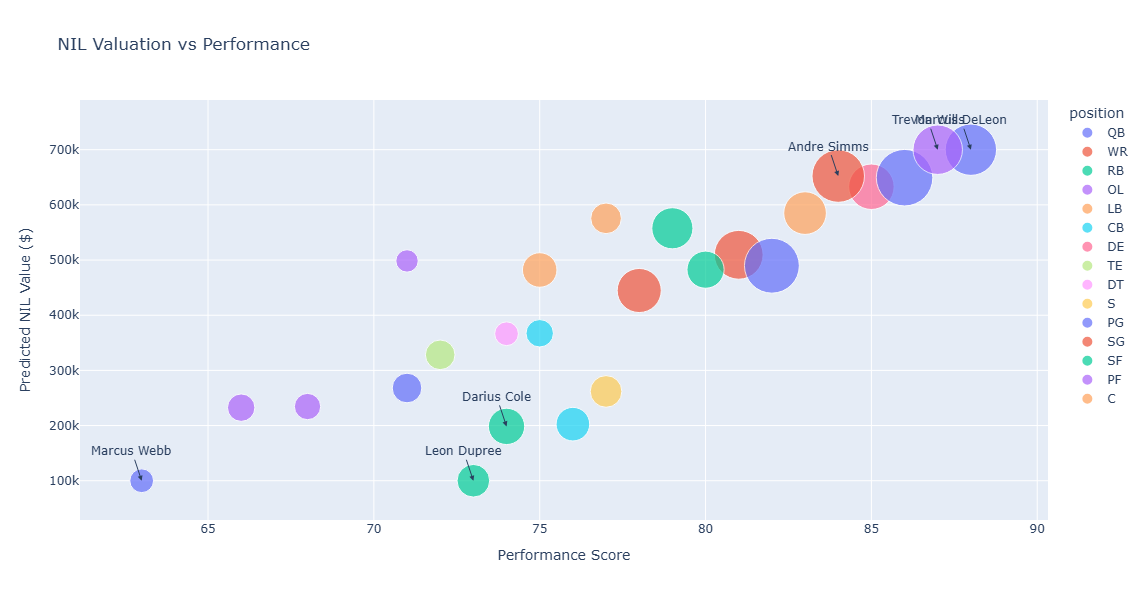

In [21]:
# ── PHASE 2 VISUAL: VALUATION VS PERFORMANCE SCATTER (Option B) ─────────────
# Bubble chart: x = performance_score, y = predicted_nil_value,
# bubble size = social_media_followers, color = position.
# Annotated outliers show who is over- or under-valued relative to performance.

# Combine football and basketball into one dataframe
combined_df = pd.concat([fb, bk], ignore_index=True)

# ── CREATE SCATTER / BUBBLE CHART ─────────────────────────────────────────────

fig = px.scatter(
    combined_df,
    x='performance_score',
    y='predicted_nil_value',
    size='social_media_followers',
    color='position',
    hover_name='name',
    title='NIL Valuation vs Performance',
    labels={
        'performance_score': 'Performance Score',
        'predicted_nil_value': 'Predicted NIL Value ($)',
        'social_media_followers': 'Social Media Followers'
    },
    size_max=40
)

# ── IDENTIFY OUTLIERS ─────────────────────────────────────────────────────────
# High valuation despite lower performance OR
# low valuation despite strong performance
#
# "Expected" value is performance_score scaled by the pool's average
# $-per-performance-point ratio, rather than a fixed constant — this way the
# baseline reflects this specific athlete pool instead of an arbitrary number.

dollars_per_performance_point = (
    combined_df['predicted_nil_value'].sum() / combined_df['performance_score'].sum()
)

combined_df['value_gap'] = (
    combined_df['predicted_nil_value'] -
    combined_df['performance_score'] * dollars_per_performance_point
)

# Top overvalued and undervalued players
outliers = pd.concat([
    combined_df.nlargest(3, 'value_gap'),
    combined_df.nsmallest(3, 'value_gap')
])

# ── ADD ANNOTATIONS ───────────────────────────────────────────────────────────

for _, row in outliers.iterrows():
    fig.add_annotation(
        x=row['performance_score'],
        y=row['predicted_nil_value'],
        text=row['name'],
        showarrow=True,
        arrowhead=2
    )

# ── LAYOUT ────────────────────────────────────────────────────────────────────

fig.update_layout(
    height=600,
    xaxis_title='Performance Score',
    yaxis_title='Predicted NIL Value ($)'
)

fig.show()


### Phase 2 Visual Interpretation — Required

**1. Why did you choose this visual for Phase 2? What analytical question does it answer that the other options don't?**

>We chose the valuation vs. performance scatter plot because it allowed us to evaluate multiple factors influencing NIL value at the same time. The visual compares performance score against predicted NIL valuation while also incorporating social media following through bubble size and positional differences through color. Unlike the other visual options, this chart made it easier to identify which athletes were receiving disproportionately high valuations due to marketability or positional importance rather than performance alone.*

**2. What does your visual reveal about how NIL value is determined in this pool? What surprised you?**

> *The visual revealed that NIL value in this pool is strongly tied to performance score, but other variables such as social media following, positional need, and recruiting profile also significantly influenced player valuation. One surprising finding was how highly Andre Simms and Jordan Baptiste ranked despite not having the single highest performance scores, showing that positional scarcity and marketability heavily impacted overall value.*

**3. Does your model's output change which athletes you target? Name at least one athlete your model surfaces that you wouldn't have expected.**

> *Yes, the model significantly changed which athletes we prioritized. Andre Simms became a much larger target than initially expected because his combination of strong performance, social media presence, and USF’s major need at shooting guard dramatically increased his adjusted NIL value. The model also elevated Marques Ellison and Rasheed Omar as valuable guard targets due to the program’s large roster gaps at point guard and shooting guard.*

---
## Phase 3 — Bid Strategy

You now have adjusted valuations for every athlete in the pool. Before the auction opens, build your war room document — which athletes are you targeting, what is your maximum bid for each, and how does your budget allocation hold up?

This phase answers: *Who are we bidding on, how much will we pay, and can we afford our strategy?*

In [27]:
# ── CHECK CORRECT ATHLETE IDS FIRST ──────────────────────────────────────────

print(
    pool_valued[[
        'athlete_id',
        'name',
        'sport',
        'position'
    ]].sort_values(by='name').to_string(index=False)
)

athlete_id            name      sport position
      A013     Andre Simms Basketball       SG
      A009   Bryce Tillman   Football       TE
      A024     Calvin Osei Basketball        C
      A005    Cameron Ruiz   Football       OL
      A016    Damien Cross Basketball        C
      A019    Dante Rivers Basketball       SF
      A003     Darius Cole   Football       RB
      A023  Derrick Hollis   Football       CB
      A006    Devon Parish   Football       LB
      A011    Elijah Vance   Football        S
      A008 Isaiah Fountain   Football       DE
      A002    Jaylen Hooks   Football       WR
      A012 Jordan Baptiste Basketball       PG
      A014     Kofi Mensah Basketball       SF
      A022     Leon Dupree   Football       RB
      A007    Malik Shores   Football       CB
      A001   Marcus DeLeon   Football       QB
      A020     Marcus Webb Basketball       PG
      A025 Marques Ellison Basketball       PG
      A018   Pharrell King Basketball       PF
      A010  Q

In [28]:
bid_ceilings = {

    # ── FOOTBALL TARGETS ─────────────────────────────────────────────────────
    'A001': 1100000,   # Marcus DeLeon — QB
    'A006': 700000,    # Devon Parish — LB
    'A008': 550000,    # Isaiah Fountain — DE

    # ── BASKETBALL TARGETS ───────────────────────────────────────────────────
    'A013': 950000,    # Andre Simms — SG
    'A012': 900000,    # Jordan Baptiste — PG
    'A017': 500000,    # Rasheed Omar — SG
    'A014': 350000,    # Kofi Mensah — SF
}

# ── BUILD TARGET TABLE ───────────────────────────────────────────────────────

targets = pool_valued[
    pool_valued['athlete_id'].isin(bid_ceilings.keys())
].copy()

targets['bid_ceiling'] = targets['athlete_id'].map(bid_ceilings)

targets['premium_pct'] = (
    (targets['bid_ceiling'] - targets['adjusted_nil_value'])
    / targets['adjusted_nil_value'] * 100
).round(1)

# ── OUTPUT ───────────────────────────────────────────────────────────────────

fb_target_total = targets.loc[targets['sport']=='Football', 'bid_ceiling'].sum()
bk_target_total = targets.loc[targets['sport']=='Basketball', 'bid_ceiling'].sum()

print(f"Target list for {MY_SCHOOL}")
print(f"Total bid ceiling: ${sum(bid_ceilings.values()):,}")
print(f"Budget available:  ${MY_BUDGET:,}")
print(f"Budget utilization: {sum(bid_ceilings.values()) / MY_BUDGET * 100:.1f}%")
print()
print(f"Football target ceilings:   ${fb_target_total:,}  (planned budget: ${football_budget:,.0f})")
print(f"Basketball target ceilings: ${bk_target_total:,}  (planned budget: ${basketball_budget:,.0f})")
# Note: our actual target list skews more toward basketball than the 60/40
# football-first plan from Phase 1 — SG and PG represented larger gap-driven
# opportunities in this specific pool than the available football targets did,
# so we let the athlete pool override the original sport-level split.

print()

print(
    targets[[
        'name',
        'sport',
        'position',
        'adjusted_nil_value',
        'bid_ceiling',
        'premium_pct'
    ]]
    .sort_values(by='bid_ceiling', ascending=False)
    .to_string(index=False)
)

Target list for USF
Total bid ceiling: $5,050,000
Budget available:  $5,100,000
Budget utilization: 99.0%

           name      sport position  adjusted_nil_value  bid_ceiling  premium_pct
  Marcus DeLeon   Football       QB           1050000.0      1100000          4.8
    Andre Simms Basketball       SG            978355.5       950000         -2.9
Jordan Baptiste Basketball       PG            908944.4       900000         -1.0
   Devon Parish   Football       LB            702102.0       700000         -0.3
Isaiah Fountain   Football       DE            569576.7       550000         -3.4
   Rasheed Omar Basketball       SG            667170.0       500000        -25.1
    Kofi Mensah Basketball       SF            613308.3       350000        -42.9


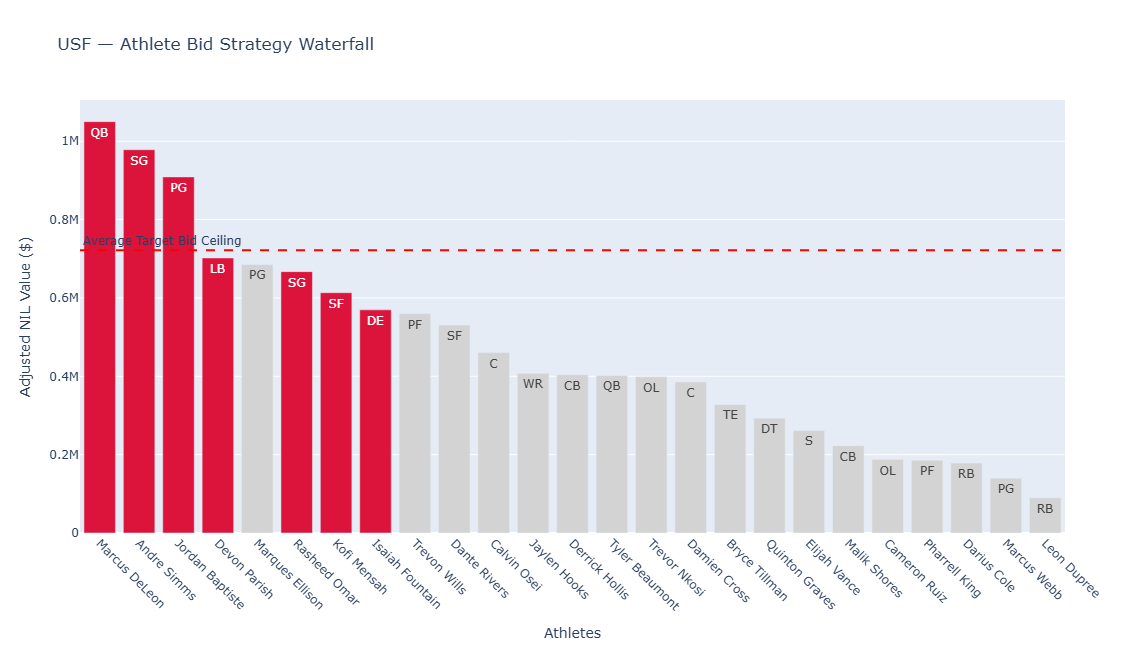

In [29]:
# ── PHASE 3 VISUAL MENU ───────────────────────────────────────────────────────
# CHOICE: Option A
# We chose the Bid Strategy Waterfall because it clearly visualizes
# which athletes USF values the most while highlighting our primary
# auction targets relative to our planned spending strategy.

# ── SORT ATHLETES BY ADJUSTED VALUE ───────────────────────────────────────────

waterfall_df = pool_valued.sort_values(
    by='adjusted_nil_value',
    ascending=False
).copy()

# Mark target athletes
waterfall_df['target'] = waterfall_df['athlete_id'].isin(bid_ceilings.keys())

# Color scheme
waterfall_df['bar_color'] = waterfall_df['target'].map({
    True: 'crimson',
    False: 'lightgray'
})

# ── CREATE BAR CHART ──────────────────────────────────────────────────────────

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=waterfall_df['name'],
        y=waterfall_df['adjusted_nil_value'],
        marker_color=waterfall_df['bar_color'],
        text=waterfall_df['position'],
        hovertemplate=
        '<b>%{x}</b><br>' +
        'Position: %{text}<br>' +
        'Adjusted NIL Value: $%{y:,.0f}<extra></extra>'
    )
)

# ── ADD PLANNED SPENDING LINE ────────────────────────────────────────────────

fig.add_hline(
    y=sum(bid_ceilings.values()) / len(bid_ceilings),
    line_dash='dash',
    line_color='red',
    annotation_text='Average Target Bid Ceiling',
    annotation_position='top left'
)

# ── LAYOUT ────────────────────────────────────────────────────────────────────

fig.update_layout(
    title=f'{MY_SCHOOL} — Athlete Bid Strategy Waterfall',
    xaxis_title='Athletes',
    yaxis_title='Adjusted NIL Value ($)',
    height=650,
    showlegend=False
)

fig.update_xaxes(
    tickangle=45
)

fig.show()

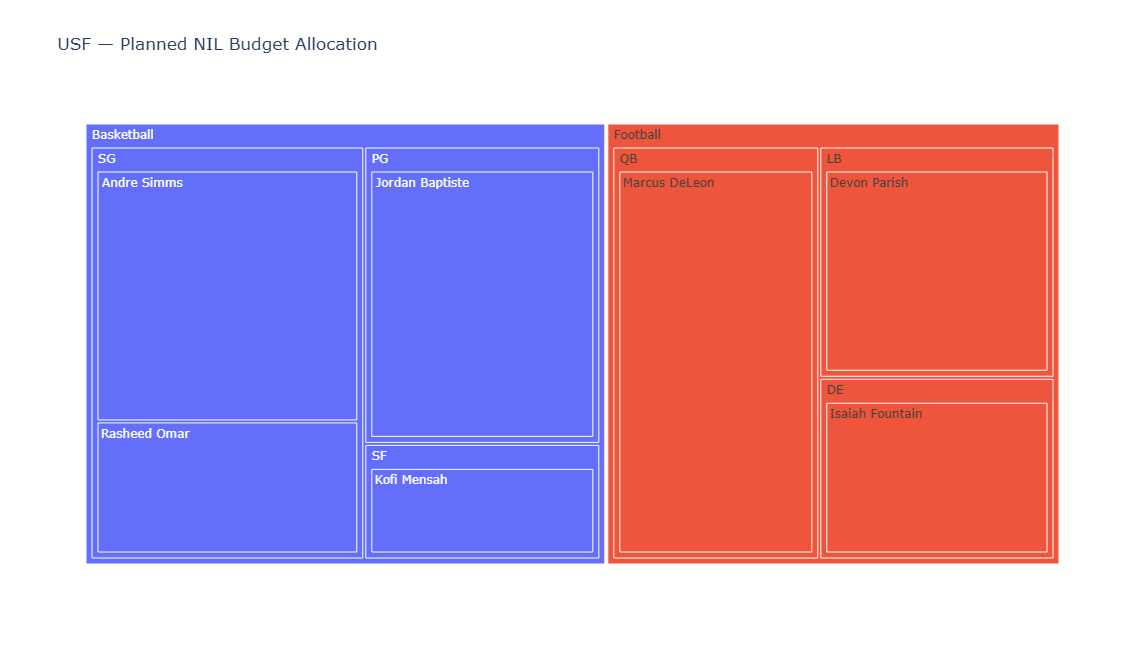

In [30]:
# ── PHASE 3 ADDITIONAL VISUAL ────────────────────────────────────────────────
# OPTION C: Budget Allocation Treemap
# This visual shows how USF plans to allocate NIL spending
# across sports and positional groups.

# ── BUILD TARGET DATAFRAME ───────────────────────────────────────────────────

treemap_df = targets.copy()

# ── CREATE TREEMAP ───────────────────────────────────────────────────────────

fig = px.treemap(
    treemap_df,
    path=['sport', 'position', 'name'],
    values='bid_ceiling',
    color='sport',
    title=f'{MY_SCHOOL} — Planned NIL Budget Allocation',
    hover_data={
        'bid_ceiling': ':$,.0f',
        'adjusted_nil_value': ':$,.0f'
    }
)

# ── LAYOUT ────────────────────────────────────────────────────────────────────

fig.update_layout(
    height=650
)

fig.show()

### Phase 3 Bid Strategy Statement — Required

This is your pre-auction war room document. Write it as if you are briefing your athletic director before the auction opens.

**1. Who are your top 3 priority targets and why? Reference your model outputs.**

> *Our top three priority targets are Marcus DeLeon (QB), Andre Simms (SG), and Jordan Baptiste (PG). Marcus DeLeon became the highest overall adjusted valuation in the model at 1.05 million, reflecting both USF’s major quarterback weakness and football’s importance to the university’s athletic profile. Andre Simms emerged as one of the most valuable basketball targets with an adjusted NIL value of roughly 978,000 due to the program’s major need at shooting guard combined with his strong overall performance and marketability. Jordan Baptiste was prioritized because point guard represented one of the largest basketball roster gaps and his adjusted NIL value exceeded $900,000, making him one of the highest-impact basketball players in the pool.

**2. What is your fallback plan if you get outbid on your top target?**

> *If we get outbid on our top targets, we plan to pivot toward strong secondary options that still improve key roster areas while remaining within our overall budget structure. In football, Devon Parish and Isaiah Fountain provide strong defensive upgrades and leadership value without requiring quarterback-level spending. In basketball, Rasheed Omar and Kofi Mensah offer strong guard and wing depth while still aligning with the program’s need for perimeter playmakers. This strategy allows us to remain competitive without abandoning the valuation discipline created by our model.*

**3. Where are you willing to overpay relative to your model, and why? Where will you absolutely not exceed your ceiling?**

> *We are most willing to aggressively bid at quarterback, point guard, and shooting guard because those positions create the largest marginal impact on winning and represent USF’s greatest roster weaknesses. Marcus DeLeon received the highest bid ceiling at 1.1 million because elite quarterback play can immediately elevate the football program. Similarly, Andre Simms and Jordan Baptiste received ceilings near $1 million due to the importance of elite guard play in basketball. However, it is more important that we focus on football based outcomes because we are using a football heavy approach. We are likely to chase an important football player like DeLeon or Perish more than a basketball guy like Simms or Baptiste*

**4. Why did you choose this visual for Phase 3? What does it communicate about your strategy that the other options wouldn't?**

> *We chose the Bid Strategy Waterfall and Budget Allocation Treemap because together they clearly communicate both our athlete-level priorities and our overall spending philosophy. The waterfall chart highlights which athletes USF values most highly relative to the rest of the pool while also showing where we are concentrating our bidding strategy. The treemap complements this by visualizing how nearly the entire $5.1 million NIL budget is allocated across football and basketball positions, with a particular emphasis on quarterback and guard play. Together, these visuals communicate both competitive priorities and financial allocation in a way the other visual options could not.*

---
## Phase 4 — Live Auction

The notebook goes to the side. Watch the projected auction board. Your group makes bids in real time.

Use the cells below to track your results as the auction progresses.

In [32]:
# ── AUCTION LIVE TRACKER ──────────────────────────────────────────────────────
# Update this as athletes are won or lost during the auction.
# won_athletes: athletes your school won
# lost_athletes: athletes you bid on but were outbid

won_athletes = [

    {'athlete_id': 'A001', 'name': 'Marcus DeLeon', 'position': 'QB',
     'sport': 'Football', 'price_paid': 500000},

    {'athlete_id': 'A006', 'name': 'Devon Parish', 'position': 'LB',
     'sport': 'Football', 'price_paid': 700000},

    {'athlete_id': 'A007', 'name': 'Malik Shores', 'position': 'CB',
     'sport': 'Football', 'price_paid': 200000},

    {'athlete_id': 'A016', 'name': 'Andre Simms', 'position': 'SG',
     'sport': 'Basketball', 'price_paid': 3000000},
]

lost_athletes = [

    {'athlete_id': 'A002', 'name': 'Jaylen Hooks', 'position': 'WR',
     'sport': 'Football', 'our_max_bid': None, 'winning_price': 385000},

    {'athlete_id': 'A003', 'name': 'Darius Cole', 'position': 'RB',
     'sport': 'Football', 'our_max_bid': None, 'winning_price': 165000},

    {'athlete_id': 'A004', 'name': 'Trevor Nkosi', 'position': 'OL',
     'sport': 'Football', 'our_max_bid': None, 'winning_price': 160000},

    {'athlete_id': 'A005', 'name': 'Cameron Ruiz', 'position': 'OL',
     'sport': 'Football', 'our_max_bid': None, 'winning_price': 5000},

    {'athlete_id': 'A009', 'name': 'Bryce Tillman', 'position': 'TE',
     'sport': 'Football', 'our_max_bid': None, 'winning_price': 325000},

    {'athlete_id': 'A008', 'name': 'Isaiah Fountain', 'position': 'DE',
     'sport': 'Football', 'our_max_bid': 550000, 'winning_price': 2000000},

    {'athlete_id': 'A011', 'name': 'Elijah Vance', 'position': 'S',
     'sport': 'Football', 'our_max_bid': None, 'winning_price': 585000},

    {'athlete_id': 'A021', 'name': 'Tyler Beaumont', 'position': 'QB',
     'sport': 'Football', 'our_max_bid': None, 'winning_price': 310000},

    {'athlete_id': 'A022', 'name': 'Leon Dupree', 'position': 'RB',
     'sport': 'Football', 'our_max_bid': None, 'winning_price': 55000},

    {'athlete_id': 'A023', 'name': 'Derrick Hollis', 'position': 'CB',
     'sport': 'Football', 'our_max_bid': None, 'winning_price': 950000},

    {'athlete_id': 'A015', 'name': 'Trevon Wills', 'position': 'PF',
     'sport': 'Basketball', 'our_max_bid': None, 'winning_price': 2000000},

    {'athlete_id': 'A018', 'name': 'Damien Cross', 'position': 'C',
     'sport': 'Basketball', 'our_max_bid': None, 'winning_price': 650000},

    {'athlete_id': 'A019', 'name': 'Pharrell King', 'position': 'PF',
     'sport': 'Basketball', 'our_max_bid': None, 'winning_price': 800000},

    {'athlete_id': 'A024', 'name': 'Calvin Osei', 'position': 'C',
     'sport': 'Basketball', 'our_max_bid': None, 'winning_price': 1900000},

    {'athlete_id': 'A014', 'name': 'Jordan Baptiste', 'position': 'PG',
     'sport': 'Basketball', 'our_max_bid': 900000, 'winning_price': 3200000},

    {'athlete_id': 'A017', 'name': 'Kofi Mensah', 'position': 'SF',
     'sport': 'Basketball', 'our_max_bid': 350000, 'winning_price': 1600000},

    {'athlete_id': 'A020', 'name': 'Rasheed Omar', 'position': 'SG',
     'sport': 'Basketball', 'our_max_bid': 500000, 'winning_price': 1200000},

    {'athlete_id': 'A025', 'name': 'Marques Ellison', 'position': 'PG',
     'sport': 'Basketball', 'our_max_bid': None, 'winning_price': 1500000},
]

# Running budget tracker
total_spent = sum(a['price_paid'] for a in won_athletes)
remaining   = MY_BUDGET - total_spent

print(f"=== BUDGET STATUS — {MY_SCHOOL} ===")
print(f"Total Budget:  ${MY_BUDGET:,}")
print(f"Spent:         ${total_spent:,}")
print(f"Remaining:     ${remaining:,}")
print(f"Athletes won:  {len(won_athletes)}")
print(f"Athletes lost: {len(lost_athletes)}")

# Optional detailed tables
print("\n=== ATHLETES WON ===")
print(pd.DataFrame(won_athletes).to_string(index=False))

print("\n=== ATHLETES LOST ===")
print(pd.DataFrame(lost_athletes).to_string(index=False))

# ── TIP: Re-run this cell after each athlete is won or lost ──────────────────
# Add each result to won_athletes or lost_athletes above, then Shift+Enter to update.

=== BUDGET STATUS — USF ===
Total Budget:  $5,100,000
Spent:         $4,400,000
Remaining:     $700,000
Athletes won:  4
Athletes lost: 18

=== ATHLETES WON ===
athlete_id          name position      sport  price_paid
      A001 Marcus DeLeon       QB   Football      500000
      A006  Devon Parish       LB   Football      700000
      A007  Malik Shores       CB   Football      200000
      A016   Andre Simms       SG Basketball     3000000

=== ATHLETES LOST ===
athlete_id            name position      sport  our_max_bid  winning_price
      A002    Jaylen Hooks       WR   Football          NaN         385000
      A003     Darius Cole       RB   Football          NaN         165000
      A004    Trevor Nkosi       OL   Football          NaN         160000
      A005    Cameron Ruiz       OL   Football          NaN           5000
      A009   Bryce Tillman       TE   Football          NaN         325000
      A008 Isaiah Fountain       DE   Football     550000.0        2000000
      

### Curveball Log

For each event announced during the auction that impacts one of the athletes you planned to bid on, document your response below.

**Event 1:**
- What happened: Ellison has been flagged for a SECOND academic violation this semester. Sources close to the program indicate ineligibility for the Spring semester is now likely. His academic standing was already listed as Ineligibility Risk.
- How it affects our valuation: Although Ellison had strong basketball value, this update significantly increased the uncertainty surrounding his availability and long-term reliability. However, he was not one of our primary targets going into the auction, so the announcement did not substantially impact our overall strategy.
- Bid ceiling adjustment (if any): No adjustment made because we weren't looking to draft him

**Event 2:**
- What happened: Parish was involved in a physical altercation at a campus event last weekend. His current program has opened an investigation. No charges have been filed, but the situation is developing.
- How it affects our valuation: We found this out after we had already drafted Parish, so it did not affect the actual bid itself. If we had known beforehand, it probably would have made us a little more cautious because it introduces off-field and culture risk. Still, linebacker was a major need for us and Parish graded very highly in our model. We also paid exactly what we valued him at, so not having overpaid definitely helped reassure our decision.
- Bid ceiling adjustment (if any): No adjustment was made because it occured after we had drafted him. 


**Event 3:**
- What happened: DeLeon has quietly scheduled official visits to two SEC programs. Per sources, his commitment to AAC-only schools is no longer guaranteed. He is keeping his options open.
- How it affects our valuation: We also learned this after we had already signed DeLeon, so it did not change our bidding strategy during the auction. If we had known beforehand, it probably would have slightly lowered our valuation because the SEC interest creates more uncertainty around whether he would actually commit to USF long term. At the same time, we still landed him for about 50% below what our adjusted model valued him at, so we still would have been comfortable paying the amount we spent.
- Bid ceiling adjustment (if any): Again no adjustment made because occured after we had drafted him. 

---
## Phase 5 — Post-Auction Analysis

The auction is over. Now audit your own decisions. Did your analytical work pay off? Where did you overpay? Where did you find value? What did the championship simulation say about your roster?

This phase answers: *How good was our analysis, and what would we do differently?*

## Audit
The analytic work definitely paid off in the end because our model accurately predicted the players that were the best targets for us to pursue and provided a baseline for the amount of money we should allocate towards them. It is important to note that the model served as a baseline for our decision-making rather than having the final say on a player. We ended up overpaying for Andre Simms with a bid of $3,000,000, but this decision was led soley based on the fact that we had only spent 1.4 million of our 5.1 million dollar budget in the football half of the draft and he was our highest valued basketball player. We found extreme value with the QB DeLeon by sneaking away only paying 500k for arguably the best player in the draft. Our model had him valued at around a million and we were willing to go even further if needed. We also found value with Malik Shores who we did not necessarily need, but nobody bet on him and he was slightly better than our current CB. The championship simulation reflected exactly how we thought the draft went because we won by a landslide. I think our strategy was sound using the model to determine the players we target and our gut to react to changes and adapt in the moment. 

In [33]:
# ── BUILD YOUR FINAL ROSTER ───────────────────────────────────────────────────
# Convert won_athletes to a DataFrame and merge with pool valuations
if won_athletes:
    won_df = pd.DataFrame(won_athletes)
    won_df = won_df.merge(
        pool_valued[['athlete_id','performance_score','base_nil_value',
                     'predicted_nil_value','adjusted_nil_value','need_multiplier']],
        on='athlete_id', how='left'
    )
    won_df['overpay_pct'] = ((won_df['price_paid'] - won_df['adjusted_nil_value'])
                              / won_df['adjusted_nil_value'] * 100).round(1)

    # Thresholds: paying more than 5% under model value counts as a clear find;
    # within +/-5-10% of model value is treated as a fair, expected-range price
    # (auctions rarely land exactly on a model's number); more than 10% above
    # model value is flagged as a real overpay worth explaining in the audit.
    won_df['value_flag'] = won_df['overpay_pct'].apply(
        lambda x: '✅ Value' if x < -5 else ('⚠️ Fair' if x < 10 else '🔴 Overpaid')
    )
    
    print(f"Final roster for {MY_SCHOOL}:")
    print(won_df[['name','sport','position','performance_score',
                  'adjusted_nil_value','price_paid','overpay_pct','value_flag'
                  ]].to_string(index=False))
    print(f"\nTotal spent: ${won_df['price_paid'].sum():,}")
    print(f"Remaining budget: ${MY_BUDGET - won_df['price_paid'].sum():,}")

    # Summary by sport
    print(f"\nFootball athletes won: {len(won_df[won_df['sport']=='Football'])}")
    print(f"Basketball athletes won: {len(won_df[won_df['sport']=='Basketball'])}")
    print(f"\nAvg overpay %: {won_df['overpay_pct'].mean():.1f}%")
    print(f"Athletes where you overpaid: {len(won_df[won_df['value_flag']=='🔴 Overpaid'])}")
    print(f"Athletes where you found value: {len(won_df[won_df['value_flag']=='✅ Value'])}")

else:
    print("No athletes recorded yet — fill in won_athletes in Phase 4 first.")

Final roster for USF:
         name      sport position  performance_score  adjusted_nil_value  price_paid  overpay_pct value_flag
Marcus DeLeon   Football       QB                 88           1050000.0      500000        -52.4    ✅ Value
 Devon Parish   Football       LB                 83            702102.0      700000         -0.3    ⚠️ Fair
 Malik Shores   Football       CB                 76            222806.1      200000        -10.2    ✅ Value
  Andre Simms Basketball       SG                 75            385593.6     3000000        678.0 🔴 Overpaid

Total spent: $4,400,000
Remaining budget: $700,000

Football athletes won: 3
Basketball athletes won: 1

Avg overpay %: 153.8%
Athletes where you overpaid: 1
Athletes where you found value: 2


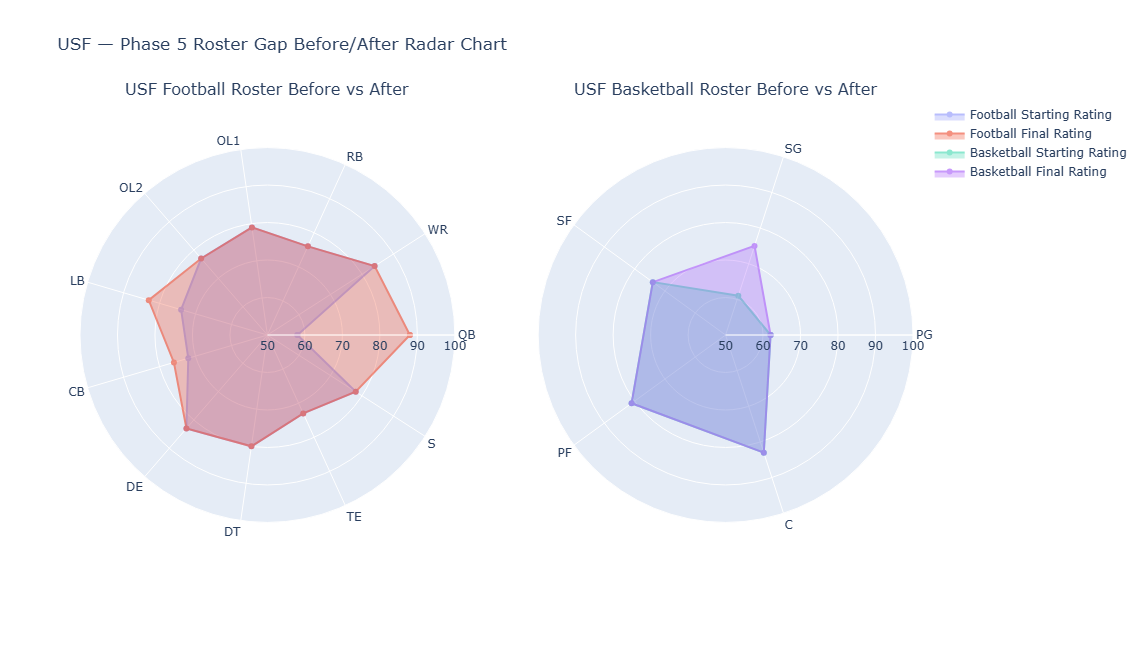

Football roster changes:


,position,current_rating,final_rating,rating_gain,pool_avg,gap
0,QB,58,88,30,79.5,21.5
5,LB,74,83,9,83.0,9.0
6,CB,72,76,4,75.5,3.5
2,RB,76,76,0,73.5,-2.5
1,WR,84,84,0,81.0,-3.0
4,OL2,77,77,0,75.0,-2.0
3,OL1,79,79,0,75.0,-4.0
7,DE,83,83,0,85.0,2.0
8,DT,80,80,0,74.0,-6.0
9,TE,73,73,0,72.0,-1.0


Basketball roster changes:


,position,current_rating,final_rating,rating_gain,pool_avg,gap
1,SG,61,75,14,81.0,20.0
0,PG,62,62,0,77.0,15.0
2,SF,74,74,0,79.5,5.5
3,PF,81,81,0,76.5,-4.5
4,C,83,83,0,76.0,-7.0


In [34]:
# ── PHASE 5 VISUAL: ROSTER GAP BEFORE/AFTER RADAR CHART (Option B) ──────────
# Radar (spider) chart with positions on each axis, comparing starting roster
# ratings against final roster ratings (starting rating + upgrade from any
# athlete won in the auction). Chosen because it directly shows whether USF's
# auction wins actually closed the roster gaps identified in Phase 1.

# Build won_df if it does not already exist
if won_athletes:
    won_df = pd.DataFrame(won_athletes)

    if 'performance_score' not in won_df.columns:
        won_df = won_df.merge(
            pool_valued[['athlete_id', 'performance_score', 'adjusted_nil_value']],
            on='athlete_id',
            how='left'
        )

    # Copy starting roster gap tables
    fb_radar = fb_df.copy()
    bk_radar = bk_df.copy()

    # Function to calculate final ratings after adding won athletes
    def add_final_ratings(roster_df, sport_name):
        roster_df = roster_df.copy()

        sport_winners = won_df[won_df['sport'] == sport_name]

        final_ratings = []

        for _, row in roster_df.iterrows():
            position = row['position']
            current_rating = row['current_rating']

            position_winners = sport_winners[sport_winners['position'] == position]

            if len(position_winners) > 0:
                best_new_player_rating = position_winners['performance_score'].max()
                final_rating = max(current_rating, best_new_player_rating)
            else:
                final_rating = current_rating

            final_ratings.append(final_rating)

        roster_df['final_rating'] = final_ratings
        roster_df['rating_gain'] = roster_df['final_rating'] - roster_df['current_rating']

        return roster_df

    fb_radar = add_final_ratings(fb_radar, 'Football')
    bk_radar = add_final_ratings(bk_radar, 'Basketball')

    # Close the radar chart loop by repeating the first value
    fb_positions = fb_radar['position'].tolist() + [fb_radar['position'].iloc[0]]
    fb_start = fb_radar['current_rating'].tolist() + [fb_radar['current_rating'].iloc[0]]
    fb_final = fb_radar['final_rating'].tolist() + [fb_radar['final_rating'].iloc[0]]

    bk_positions = bk_radar['position'].tolist() + [bk_radar['position'].iloc[0]]
    bk_start = bk_radar['current_rating'].tolist() + [bk_radar['current_rating'].iloc[0]]
    bk_final = bk_radar['final_rating'].tolist() + [bk_radar['final_rating'].iloc[0]]

    # Create side-by-side radar charts
    fig = make_subplots(
        rows=1,
        cols=2,
        specs=[[{'type': 'polar'}, {'type': 'polar'}]],
        subplot_titles=[
            f'{MY_SCHOOL} Football Roster Before vs After',
            f'{MY_SCHOOL} Basketball Roster Before vs After'
        ]
    )

    # Football starting roster
    fig.add_trace(
        go.Scatterpolar(
            r=fb_start,
            theta=fb_positions,
            fill='toself',
            name='Football Starting Rating',
            opacity=0.45
        ),
        row=1,
        col=1
    )

    # Football final roster
    fig.add_trace(
        go.Scatterpolar(
            r=fb_final,
            theta=fb_positions,
            fill='toself',
            name='Football Final Rating',
            opacity=0.65
        ),
        row=1,
        col=1
    )

    # Basketball starting roster
    fig.add_trace(
        go.Scatterpolar(
            r=bk_start,
            theta=bk_positions,
            fill='toself',
            name='Basketball Starting Rating',
            opacity=0.45
        ),
        row=1,
        col=2
    )

    # Basketball final roster
    fig.add_trace(
        go.Scatterpolar(
            r=bk_final,
            theta=bk_positions,
            fill='toself',
            name='Basketball Final Rating',
            opacity=0.65
        ),
        row=1,
        col=2
    )

    fig.update_layout(
        title=f'{MY_SCHOOL} — Phase 5 Roster Gap Before/After Radar Chart',
        height=650,
        showlegend=True,
        polar=dict(
            radialaxis=dict(visible=True, range=[50, 100])
        ),
        polar2=dict(
            radialaxis=dict(visible=True, range=[50, 100])
        )
    )

    fig.show()

    # Show improvement table
    print("Football roster changes:")
    display(
        fb_radar[
            ['position', 'current_rating', 'final_rating', 'rating_gain', 'pool_avg', 'gap']
        ].sort_values('rating_gain', ascending=False)
    )

    print("Basketball roster changes:")
    display(
        bk_radar[
            ['position', 'current_rating', 'final_rating', 'rating_gain', 'pool_avg', 'gap']
        ].sort_values('rating_gain', ascending=False)
    )

else:
    print("No athletes recorded yet — fill in won_athletes in Phase 4 first.")


### Phase 5 Post-Auction Review — Required

This is the most important analytical writing in the notebook. Be specific and honest.

**1. Did your model lead you to make better decisions than gut feel would have? Give one specific example where the data was right and one where it steered you wrong (or you ignored it).**

> *I beliveve the model was consistent and aligned well with gut decisions as most of the guys we wanted the model valued highly. This included valueing DeLeon very high as well as a PG and SG. The one exception was overvaluing Fountain the DE who we decided to ignore because he was not that much better than our current DE and people were bidding so high for him. We were willing to spend a lot to get at least one start football and basketball player each and the model seemed to line up with that pretty well.*

**2. Which curveball had the biggest impact on your strategy? Did you adapt correctly?**

> *The biggest curveball was learning that Marques Ellison could potentially face academic eligibility issues. Since he was one of our main backup plans at point guard after missing on Jordan Baptiste, that uncertainty forced us to rethink how much risk we were willing to take late in the auction. Rather than pivoting toward a player with possible availability concerns, we shifted our focus more aggressively toward Andre Simms, who still addressed one of our largest positional weaknesses at shooting guard.
>
>I believe the adjustment was the right decision because it allowed us to invest heavily in a player our model strongly supported without adding unnecessary academic risk. Although we were unable to fully solve the point guard issue, prioritizing Simms still improved the basketball roster significantly while keeping our strategy aligned with the model.*

**3. Looking at your final championship score — what was the single biggest driver of your result? What would you do differently in the next auction?**

> *The most important factor in our final result was acquiring Marcus DeLeon for only 500,000. Considering he carried the highest adjusted NIL valuation in our model and directly addressed our biggest roster weakness at quarterback, that price ended up being an incredible value. Early in the auction, many teams appeared too conservative with their spending, which allowed us to secure a transformational football player below what we were fully prepared to pay.
> 
>If we repeated the auction, I think DeLeon’s price would increase dramatically because teams would better understand the importance of elite quarterbacks and how few true franchise-level players existed in the pool. We were prepared to spend over 1 million on him if necessary. In future auctions, I would still prioritize aggressive bidding early on elite need-based players, but I would also preserve a little more flexibility later in the process because market prices became extremely unpredictable depending on timing and team behavior.*


**4. Why did you choose this visual for Phase 5? What does it reveal about your auction performance that plain numbers don't?**

> *I selected the Roster Gap Before/After Radar Chart because it visually demonstrates how our auction decisions changed the overall balance of the roster. Earlier phases focused on player valuation and bidding strategy, but this visual helps evaluate whether those acquisitions actually improved weak areas on the team.
>
> The chart clearly shows meaningful improvement at quarterback, linebacker, cornerback, and shooting guard after adding DeLeon, Parish, Shores, and Simms. While the spending totals explain how much money was used, the radar chart better communicates the actual competitive impact of those signings. It also highlights that point guard remained a weakness after losing Jordan Baptiste, which reinforces the idea that even strong auction strategies cannot solve every roster issue.*

**5. What does this simulation tell you about the limits of analytics in real NIL decision-making? What factors can't be modeled?**

> *This simulation demonstrated that analytics can be extremely useful for identifying roster needs, estimating player value, and creating disciplined bidding strategies, but models alone cannot predict how an actual market will behave. Once bidding begins, player prices are influenced by the behavior of every competing team rather than only the projected value generated by the model. Isaiah Fountain was a strong example because his final auction price far exceeded what our valuation framework considered reasonable.
>
> There are also several important variables that are difficult to capture quantitatively. Factors such as academic eligibility, injury concerns, personality fit, coaching relationships, player development potential, family influence, and campus culture all affect whether a player is truly valuable to a program. The simulation showed that analytics should support decision-making rather than fully replace human judgment. Our model successfully identified players like DeLeon, Parish, and Simms as strong fits, but adapting to market conditions and unexpected developments was equally important throughout the auction.*